# NLP Sentiment Classifer LSTM Mark 1 

* Building a simple insight sentiment classifier.

* We will use the GoEmotions datset from Google.
  - https://github.com/google-research/google-research/tree/master/goemotions?utm_source=chatgpt.com

* GoEmotions is a corpus of 58k carefully curated comments extracted from Reddit, with human annotations to 27 emotion categories or Neutral.
  - Number of examples: 58,009.

  - Number of labels: 27 + Neutral.

  - Maximum sequence length in training and evaluation datasets: 30.

* On top of the raw data, we also include a version filtered based on reter-agreement, which contains a train/test/validation split:
  - Size of training dataset: 43,410.

  - Size of test dataset: 5,427.

  - Size of validation dataset: 5,426.

* The emotion categories are: admiration, amusement, anger, annoyance, approval, caring, confusion, curiosity, desire, disappointment, disapproval, disgust, embarrassment, excitement, fear, gratitude, grief, joy, love, nervousness, optimism, pride, realization, relief, remorse, sadness, surprise.


In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

## Loading in the training data.

* Using the official preprocessed GoEmotions training split.

* Each text example is associated with one or more emotion labels.

* For this project, we will create a SINGLE-label classification task.

In [2]:
# Load the training data.
train_df = pd.read_csv(
    "data/preprocessed/train.tsv",
    sep="\t",
    header=None,
    names=["text", "emotion_ids", "id"]
)

train_df.head()

,text,emotion_ids,id
0,My favourite food is anything I didn't have to...,27,eebbqej
1,"Now if he does off himself, everyone will thin...",27,ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,2,eezlygj
3,To make her feel threatened,14,ed7ypvh
4,Dirty Southern Wankers,3,ed0bdzj


In [4]:
print(train_df.columns)

Index(['text', 'emotion_ids', 'id'], dtype='str')


In [5]:
print(train_df.shape)

(43410, 3)


## EDA

In [7]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43410 entries, 0 to 43409
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   text         43410 non-null  str  
 1   emotion_ids  43410 non-null  str  
 2   id           43410 non-null  str  
dtypes: str(3)
memory usage: 1017.6 KB


* We have 43,140 rows with no missing or null values.

* The data type for all rows are strings.

In [8]:
# Most common emotion ID in the training set?
train_df['emotion_ids'].value_counts()

emotion_ids
27            12823
0              2710
4              1873
15             1857
1              1652
              ...  
0,12,13,26        1
1,2,5,17          1
13,14             1
3,9,12            1
0,1,18            1
Name: count, Length: 711, dtype: int64

In [9]:
# 27 is the most common id with a count of 12823.

# Some class imblance.

train_df['emotion_ids'].value_counts().head(20)

emotion_ids
27    12823
0      2710
4      1873
15     1857
1      1652
3      1451
18     1427
10     1402
7      1389
2      1025
20      861
6       858
17      853
25      817
26      720
9       709
5       649
22      586
13      510
11      498
Name: count, dtype: int64

* GoEmotions has a fixed mapping from IDs to emotions.
  - admiration
amusement
anger
annoyance
approval
caring
confusion
curiosity
desire
disappointment
disapproval
disgust
embarrassment
excitement
fear
gratitude
grief
joy
love
nervousness
optimism
pride
realization
relief
remorse
sadness
surprise
neutral

In [10]:
emotion_labels = [
    "admiration", "amusement", "anger", "annoyance", "approval",
    "caring", "confusion", "curiosity", "desire", "disappointment",
    "disapproval", "disgust", "embarrassment", "excitement", "fear",
    "gratitude", "grief", "joy", "love", "nervousness", "optimism",
    "pride", "realization", "relief", "remorse", "sadness",
    "surprise", "neutral"
]

for i, emotion in enumerate(emotion_labels):
  print(i, emotion)

0 admiration
1 amusement
2 anger
3 annoyance
4 approval
5 caring
6 confusion
7 curiosity
8 desire
9 disappointment
10 disapproval
11 disgust
12 embarrassment
13 excitement
14 fear
15 gratitude
16 grief
17 joy
18 love
19 nervousness
20 optimism
21 pride
22 realization
23 relief
24 remorse
25 sadness
26 surprise
27 neutral


In [11]:
train_df['emotion_ids'].nunique()

711

In [12]:
# Some of the dataset is multi-labled, NOT single-labeled.

# Hence why we ended up 711 unique values.
train_df["emotion_ids"].unique()[:30]

<StringArray>
[    '27',      '2',     '14',      '3',     '26',     '15',   '8,20',
      '0',      '6',    '1,4',      '5',   '3,12',   '6,22', '6,9,27',
     '12',  '16,25',    '2,7',     '17',     '25',   '0,15',  '15,18',
  '16,27',   '7,13',     '10',     '20',      '4',  '13,15',    '0,1',
     '13',      '1']
Length: 30, dtype: str

In [13]:
# Multi-labeled emotion id's contain ",", so let's count how many are multi-labeled.
train_df['emotion_ids'].str.contains(',').value_counts()

emotion_ids
False    36308
True      7102
Name: count, dtype: int64

In [14]:
train_df['emotion_ids'].str.contains(',').value_counts()

emotion_ids
False    36308
True      7102
Name: count, dtype: int64

In [15]:
total_count = len(train_df)
multi_labeled_count = train_df['emotion_ids'].str.contains(',').sum()
single_labeled_count = (~train_df['emotion_ids'].str.contains(',')).sum()

print(f"Total data points: {total_count}")
print(f"Single-labeled data points: {single_labeled_count}")
print(f"Multi-labeled data points: {multi_labeled_count}")

Total data points: 43410
Single-labeled data points: 36308
Multi-labeled data points: 7102


## Single-Labeled Data

* For this project, we will work with just the single-labeled data points.

* That gives us 36308 data points.

In [16]:
single_label_df = train_df[
  ~(train_df['emotion_ids'].str.contains(','))
].copy()

In [17]:
single_label_df.head()

,text,emotion_ids,id
0,My favourite food is anything I didn't have to...,27,eebbqej
1,"Now if he does off himself, everyone will thin...",27,ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,2,eezlygj
3,To make her feel threatened,14,ed7ypvh
4,Dirty Southern Wankers,3,ed0bdzj


In [18]:
single_label_df.shape

(36308, 3)

In [19]:
# Convert emotion_ids to int.
single_label_df['emotion_ids'] = single_label_df['emotion_ids'].astype(int)
single_label_df.head()

,text,emotion_ids,id
0,My favourite food is anything I didn't have to...,27,eebbqej
1,"Now if he does off himself, everyone will thin...",27,ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,2,eezlygj
3,To make her feel threatened,14,ed7ypvh
4,Dirty Southern Wankers,3,ed0bdzj


### Mapping the Emotion IDs

In [20]:
single_label_df['emotion_ids']

0        27
1        27
2         2
3        14
4         3
         ..
43405    18
43406     6
43407     3
43408    13
43409    17
Name: emotion_ids, Length: 36308, dtype: int64

In [21]:
with open("data/preprocessed/emotions.txt") as f:
  emotion_labels = [line.strip() for line in f if line.strip()]

emotion_labels

['admiration',
 'amusement',
 'anger',
 'annoyance',
 'approval',
 'caring',
 'confusion',
 'curiosity',
 'desire',
 'disappointment',
 'disapproval',
 'disgust',
 'embarrassment',
 'excitement',
 'fear',
 'gratitude',
 'grief',
 'joy',
 'love',
 'nervousness',
 'optimism',
 'pride',
 'realization',
 'relief',
 'remorse',
 'sadness',
 'surprise',
 'neutral']

In [22]:
emotion_mapping = dict(enumerate(emotion_labels))
emotion_mapping

{0: 'admiration',
 1: 'amusement',
 2: 'anger',
 3: 'annoyance',
 4: 'approval',
 5: 'caring',
 6: 'confusion',
 7: 'curiosity',
 8: 'desire',
 9: 'disappointment',
 10: 'disapproval',
 11: 'disgust',
 12: 'embarrassment',
 13: 'excitement',
 14: 'fear',
 15: 'gratitude',
 16: 'grief',
 17: 'joy',
 18: 'love',
 19: 'nervousness',
 20: 'optimism',
 21: 'pride',
 22: 'realization',
 23: 'relief',
 24: 'remorse',
 25: 'sadness',
 26: 'surprise',
 27: 'neutral'}

In [23]:
# Map the IDs in dataframe.
single_label_df['emotion'] = single_label_df['emotion_ids'].map(emotion_mapping)
single_label_df.head()

,text,emotion_ids,id,emotion
0,My favourite food is anything I didn't have to...,27,eebbqej,neutral
1,"Now if he does off himself, everyone will thin...",27,ed00q6i,neutral
2,WHY THE FUCK IS BAYLESS ISOING,2,eezlygj,anger
3,To make her feel threatened,14,ed7ypvh,fear
4,Dirty Southern Wankers,3,ed0bdzj,annoyance


In [24]:
# Check on Class Distribution.
class_distribution = single_label_df['emotion'].value_counts()
class_distribution

emotion
neutral           12823
admiration         2710
approval           1873
gratitude          1857
amusement          1652
annoyance          1451
love               1427
disapproval        1402
curiosity          1389
anger              1025
optimism            861
confusion           858
joy                 853
sadness             817
surprise            720
disappointment      709
caring              649
realization         586
excitement          510
disgust             498
fear                430
desire              389
remorse             353
embarrassment       203
relief               88
nervousness          85
pride                51
grief                39
Name: count, dtype: int64

In [25]:
print(f"Number of emotion classes: {single_label_df['emotion'].nunique()}")
print(f"Most common emotion: {class_distribution.index[0]} ({class_distribution.iloc[0]:,})")
print(f"Least common emotion: {class_distribution.index[-1]} ({class_distribution.iloc[-1]:,})")

Number of emotion classes: 28
Most common emotion: neutral (12,823)
Least common emotion: grief (39)


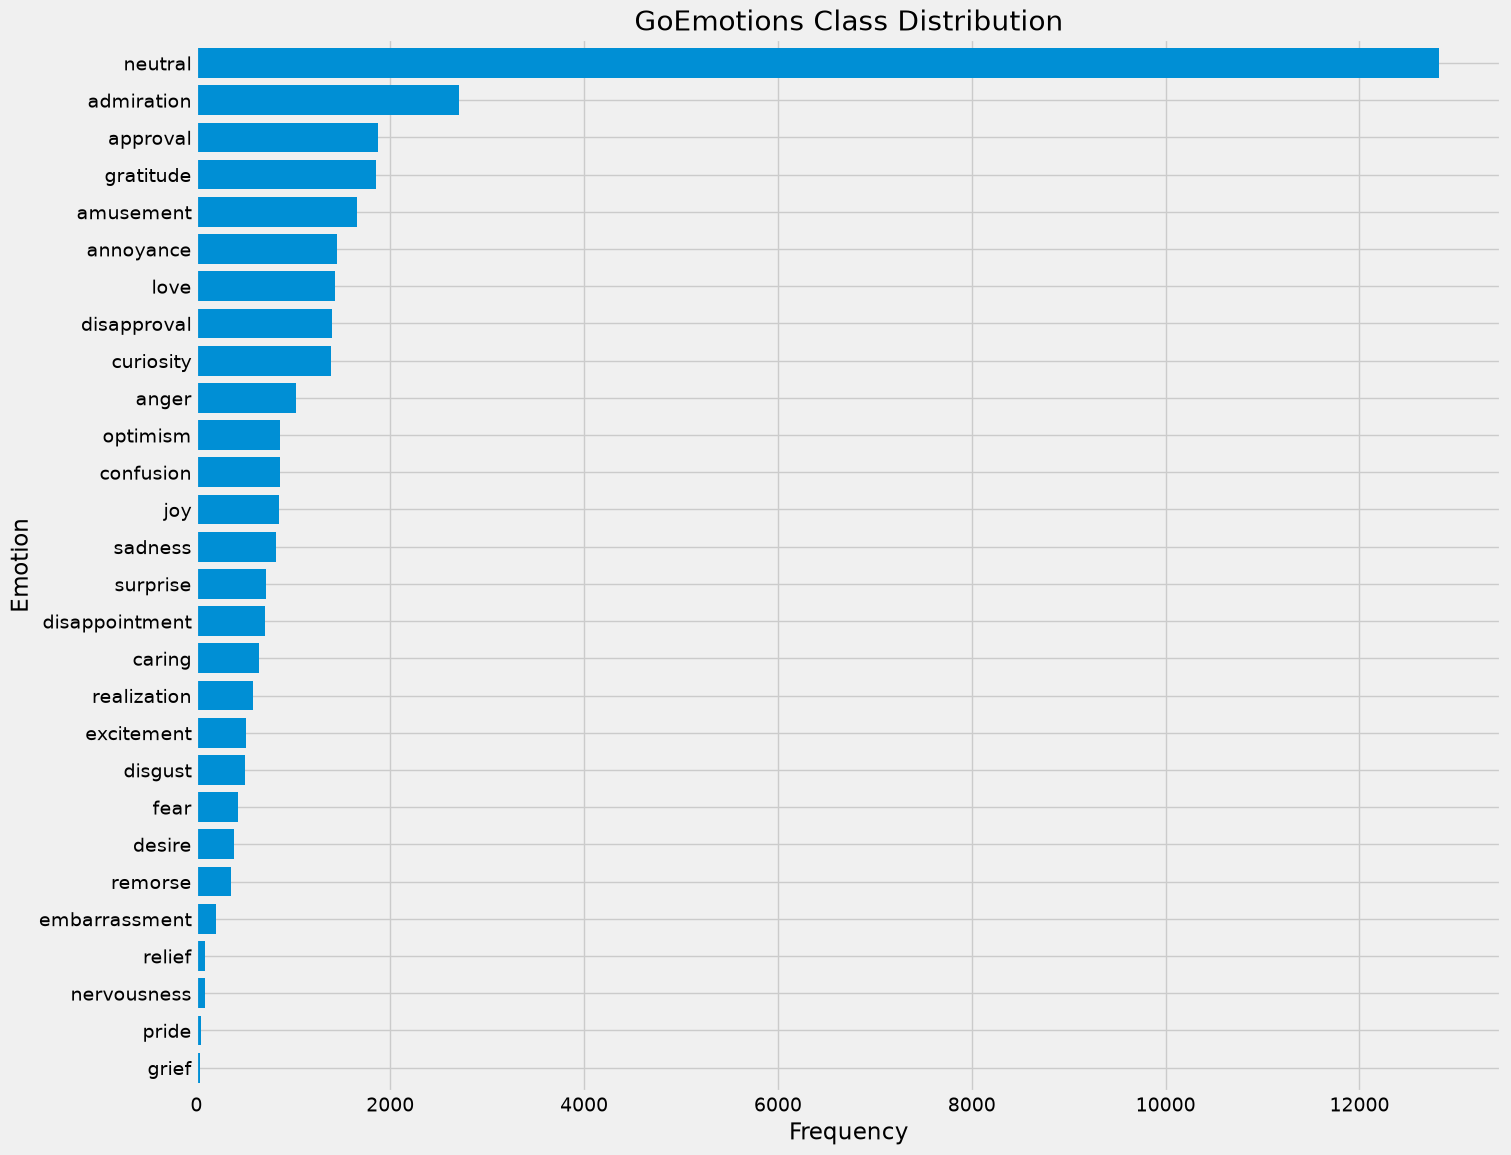

In [26]:
plt.style.use('fivethirtyeight')
class_distribution.sort_values().plot(
    kind="barh",
    figsize=(15, 13), 
    width=0.8
)

plt.xlabel("Frequency")
plt.ylabel("Emotion")
plt.title("GoEmotions Class Distribution")
plt.show()

In [27]:
class_distribution.index

Index(['neutral', 'admiration', 'approval', 'gratitude', 'amusement',
       'annoyance', 'love', 'disapproval', 'curiosity', 'anger', 'optimism',
       'confusion', 'joy', 'sadness', 'surprise', 'disappointment', 'caring',
       'realization', 'excitement', 'disgust', 'fear', 'desire', 'remorse',
       'embarrassment', 'relief', 'nervousness', 'pride', 'grief'],
      dtype='str', name='emotion')

In [28]:
class_distribution.values

array([12823,  2710,  1873,  1857,  1652,  1451,  1427,  1402,  1389,
        1025,   861,   858,   853,   817,   720,   709,   649,   586,
         510,   498,   430,   389,   353,   203,    88,    85,    51,
          39])

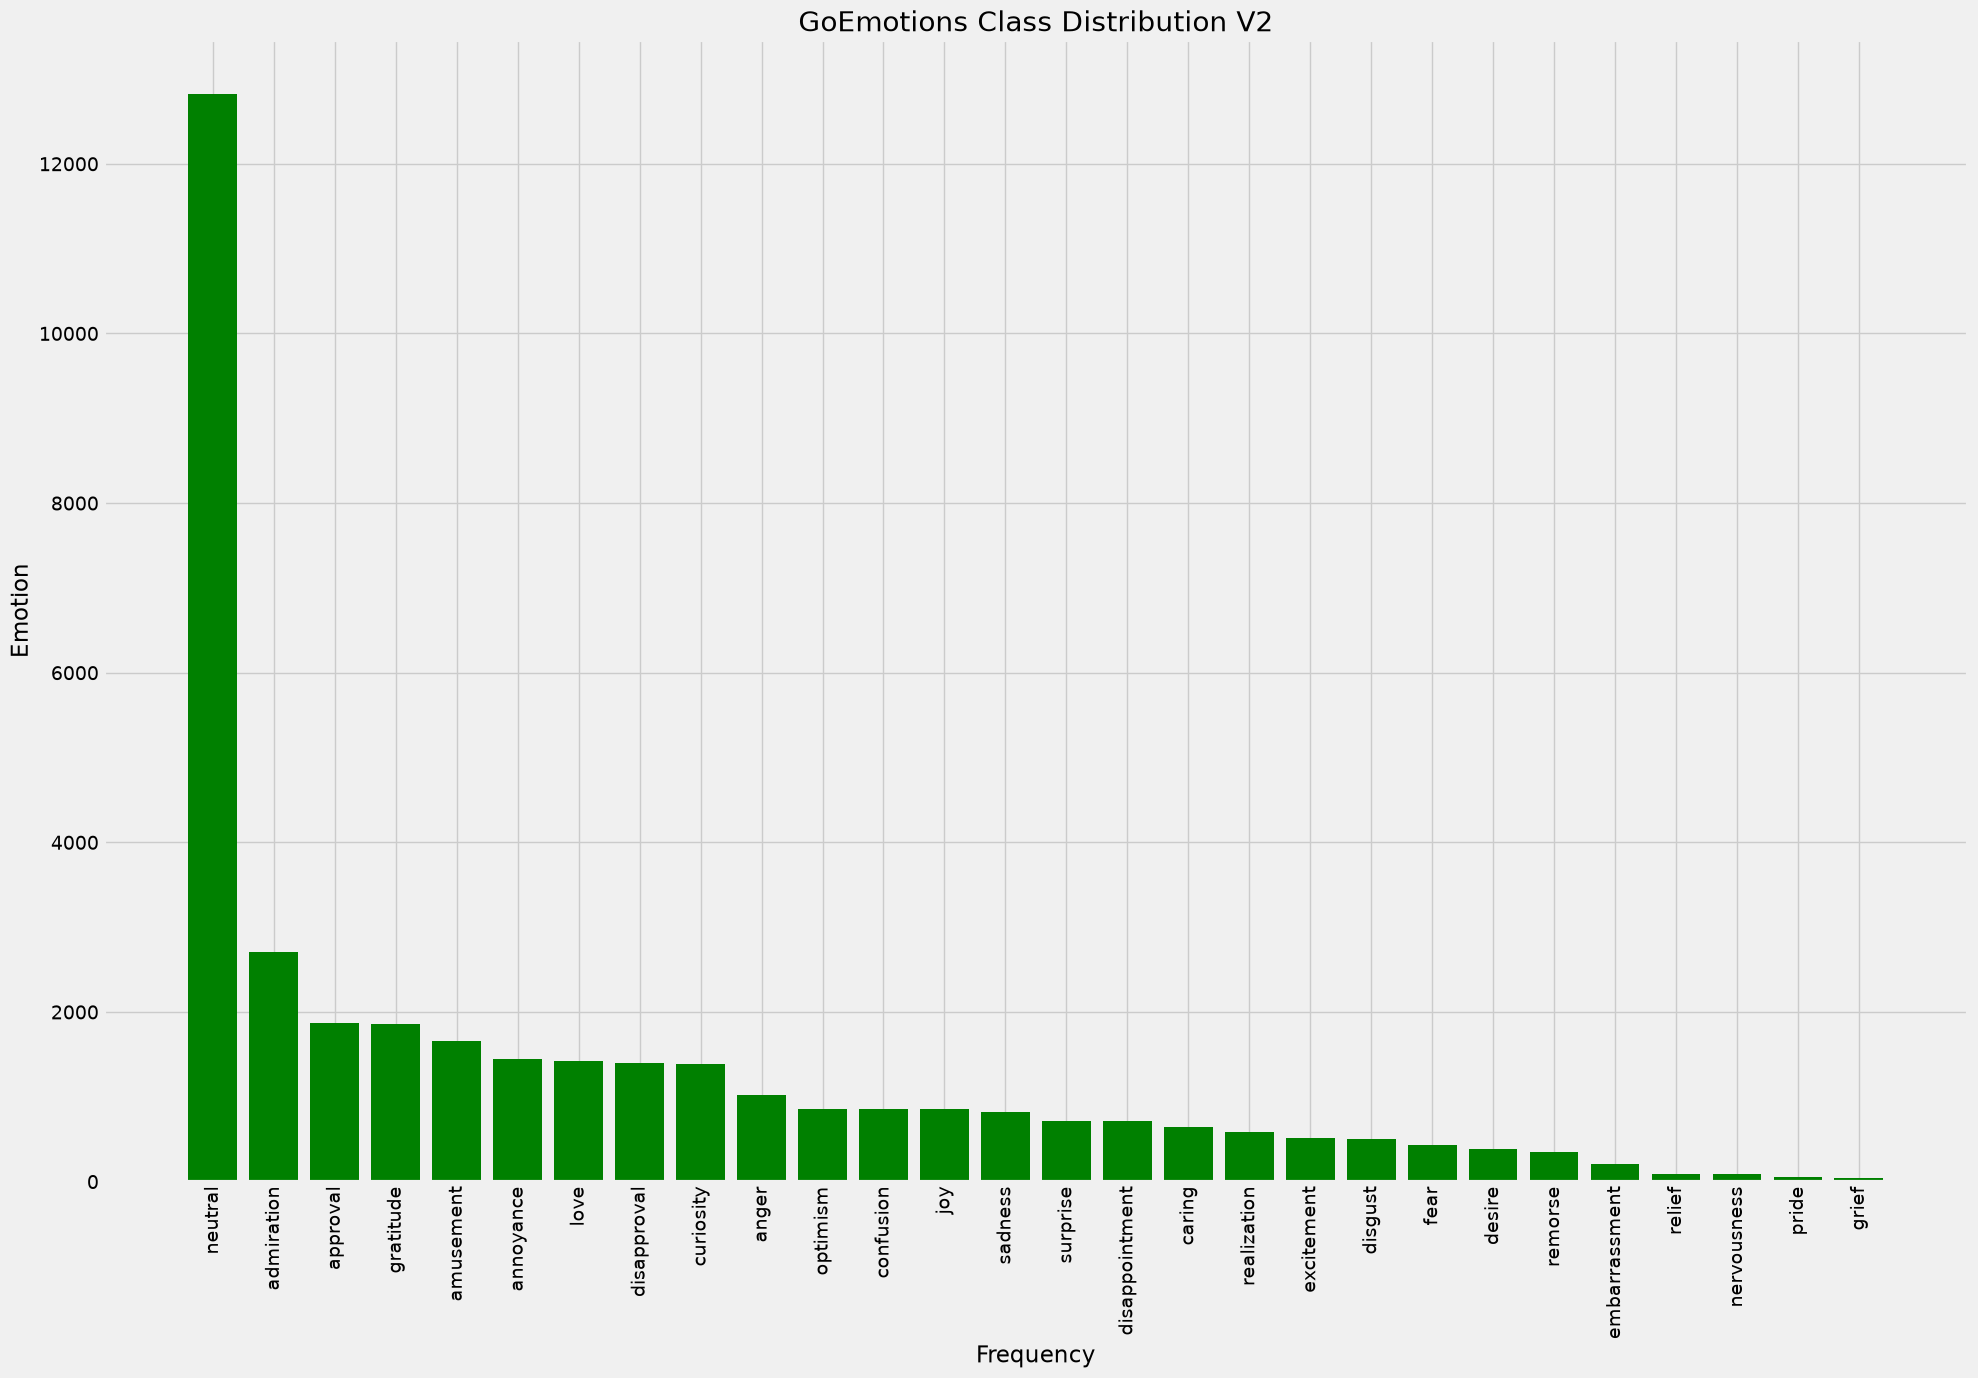

In [29]:
plt.style.use('fivethirtyeight')

plt.figure(figsize=(20, 14))
width=0.8

plt.bar(class_distribution.index, class_distribution.values, width=width, color='green')

plt.title("GoEmotions Class Distribution V2")
plt.xlabel("Frequency")
plt.ylabel("Emotion")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [30]:
# Validate there are no missing values.
print(single_label_df[['text', 'emotion']].isnull().sum())

text       0
emotion    0
dtype: int64


## X and Y Training Split

In [31]:
single_label_df.head()

,text,emotion_ids,id,emotion
0,My favourite food is anything I didn't have to...,27,eebbqej,neutral
1,"Now if he does off himself, everyone will thin...",27,ed00q6i,neutral
2,WHY THE FUCK IS BAYLESS ISOING,2,eezlygj,anger
3,To make her feel threatened,14,ed7ypvh,fear
4,Dirty Southern Wankers,3,ed0bdzj,annoyance


In [32]:
x = single_label_df['text']
x.head()

0    My favourite food is anything I didn't have to...
1    Now if he does off himself, everyone will thin...
2                       WHY THE FUCK IS BAYLESS ISOING
3                          To make her feel threatened
4                               Dirty Southern Wankers
Name: text, dtype: str

In [33]:
y = single_label_df['emotion']
y

0           neutral
1           neutral
2             anger
3              fear
4         annoyance
            ...    
43405          love
43406     confusion
43407     annoyance
43408    excitement
43409           joy
Name: emotion, Length: 36308, dtype: str

In [34]:
print(f'Features: {x.shape}')
print(f'Target: {y.shape}')

Features: (36308,)
Target: (36308,)


### Splitting the data into training and test sets.

* stratify() ensures the proportion of different classes in our target stays approximately the same in both training and testing sets.

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
X_train, X_val, y_train, y_val = train_test_split(
  x, 
  y, 
  test_size=0.33, 
  random_state=42, 
  stratify=y
)

In [37]:
print(f'Training Data: {len(X_train)}')
print(f'Validation Data: {len(X_val)}')

Training Data: 24326
Validation Data: 11982


In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

## Why LSTM

* Moving on to long short-term memory approach.
  - We will be able to process the tokens sequentially.

* EX:
  - TF-IDF represents a sentence "I love this game" but doesn't inherently understand the sequence.

  - LSTMs process tokens sequentially, maintaining a hidden(short-term memory) state, providing a mechanism for capturing context and word order.

### Building the LSTM

* We'll want to first tokenize the text from GoEmotions, assign integer token IDs, and apply padding.

* Next we'll build the Embedding layer, where we set up the LSTM and the dense output layer.

* NOTE: TensorFlow does not yet have published wheels for Python 3.14. Need to use Python 3.12.
  - Alternative is to use pytorch

In [39]:
import sys
print(sys.version)

3.14.4 (main, Apr  7 2026, 13:13:20) [Clang 21.0.0 (clang-2100.0.123.102)]


In [41]:
# %pip install torch torchvision torchaudio

In [42]:
import torch 
import torch.nn as nn 
from torch.utils.data import Dataset, DataLoader 
from collections import Counter 
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
import re

### Build Out Vocabulary from Training Text

* LSTM's Embedding layer can only handle numerical input.

* Building out a vocabulary will enable us to convert raw text into integers the model can use.

  - EX: "I feel happy today"

In [44]:
# Convert to lowercase.
# Use regex to scan string and return only:
# \w --> matches any word characters(a-z, 0-9, underscore). NO punctuation, spaces, symbols.
# + --> one or more. We want one or more consecutive word characters.
# \b --> word boundary that anchors where a match can start or stop.
example_text = "I'm SO happy!! :)"
re.findall(r"\b\w+\b", example_text.lower())

['i', 'm', 'so', 'happy']

In [45]:
example_text = "don't stop-believing"
re.findall(r"\b\w+\b", example_text.lower())

['don', 't', 'stop', 'believing']

In [46]:
def simple_tokenize(text):
  # Convert to lowercase.
  # Use regex to scan string and return only:
  # \w --> matches any word characters(a-z, 0-9, underscore). NO punctuation, spaces, symbols.
  # + --> one or more. We want one or more consecutive word characters.
  # \b --> word boundary that anchors where a match can start or stop.
  return re.findall(r"\b\w+\b", text.lower())

In [47]:
simple_tokenize(example_text)

['don', 't', 'stop', 'believing']

In [48]:
X_train

459      I'm curious though, will they upvote it to own...
23430    i'm just making fun of how when moids say they...
18493                                      I will! Thanks!
16724    $11 an hour doesn't leave a lot of room to be ...
17768                                     Oh okay. Thanks.
                               ...                        
13315    Fuck it, maybe the faceless men worship the gr...
25736    I drive semi trucks into denver. Im not there ...
10516    Yeah you're right, I mistyped it. Should have ...
26792    Yes, he's really pushing the Devils to new hei...
23429                                    Resting cash face
Name: text, Length: 24326, dtype: str

In [49]:
# min_df=2 controls which tokens survive, regardless of whether they're unigrams or bigrams
# Only keep token if it appears in at least 2 different documents, otherwise drop it.
count_vec = CountVectorizer(min_df=2, lowercase=True)
count_vec.fit(X_train)

,"min_df min_df: float in range [0.0, 1.0] or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float, the parameter represents a proportion of documents, integerabsolute counts.This parameter is ignored if vocabulary is not None.",2
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"


In [50]:
# Reserve 0 and 1 for padding and unknown tokens respectively. 
# Shift everything else up by 2.

# count_vec.vocabulary_ (CountVectorizer's own numbering):
# {"happy": 0, "sad": 1, "grief": 2}

# vocab (yours, after the shift):
# {"<PAD>": 0, "<UNK>": 1, "happy": 2, "sad": 3, "grief": 4}
vocab = {"<PAD>": 0, "<UNK>": 1}
for word, idx in count_vec.vocabulary_.items():
    vocab[word] = idx + 2

print(f"Vocabulary size: {len(vocab)}")

Vocabulary size: 9378


In [51]:
vocab

{'<PAD>': 0,
 '<UNK>': 1,
 'curious': 2129,
 'though': 8372,
 'will': 9183,
 'they': 8348,
 'upvote': 8847,
 'it': 4436,
 'to': 8455,
 'own': 5843,
 'the': 8324,
 'libs': 4775,
 'name': 5421,
 'just': 4528,
 'making': 4981,
 'fun': 3461,
 'of': 5665,
 'how': 4073,
 'when': 9141,
 'say': 7193,
 'like': 4798,
 'personality': 6034,
 'dont': 2590,
 'really': 6696,
 'mean': 5083,
 'thanks': 8317,
 '11': 14,
 'an': 455,
 'hour': 4064,
 'doesn': 2567,
 'leave': 4720,
 'lot': 4907,
 'room': 7057,
 'be': 870,
 'hero': 3927,
 'oh': 5689,
 'okay': 5699,
 'told': 8467,
 'you': 9348,
 'all': 397,
 'bravo': 1168,
 'killing': 4572,
 'in': 4199,
 'your': 9353,
 'home': 3999,
 'self': 7308,
 'defense': 2275,
 'is': 4422,
 'now': 5594,
 'bad': 769,
 'thing': 8356,
 'that': 8319,
 'was': 9060,
 'not': 5578,
 'even': 2948,
 'under': 8745,
 'discussion': 2491,
 'its': 4442,
 'acts': 262,
 'as': 619,
 'barrier': 831,
 'so': 7659,
 'bread': 1173,
 'wont': 9242,
 'get': 3557,
 'soggy': 7680,
 'no': 5541,
 'ma

In [54]:
# takes the vocab we built and converts every text into a LIST OF INTEGERS.
def text_to_ids(text, vocab):
    # The second parameter is the "UNKNOWN" value when we find a non-existing word in our dictionary.
    return [vocab.get(word_token, vocab["<UNK>"]) for word_token in simple_tokenize(text)]

train_sequences = [text_to_ids(t, vocab) for t in X_train]
val_sequences = [text_to_ids(t, vocab) for t in X_val]

In [55]:
train_sequences

[[1, 1, 2129, 8372, 9183, 8348, 8847, 4436, 8455, 5843, 8324, 4775, 5421],
 [1,
  1,
  4528,
  4981,
  3461,
  5665,
  4073,
  9141,
  1,
  7193,
  8348,
  4798,
  6034,
  8348,
  2590,
  6696,
  5083,
  4436],
 [1, 9183, 8317],
 [14, 455, 4064, 2567, 1, 4720, 1, 4907, 5665, 7057, 8455, 870, 1, 3927],
 [5689, 5699, 8317],
 [8467, 9348, 397, 1168],
 [4572,
  455,
  1,
  4199,
  9353,
  3999,
  4199,
  7308,
  2275,
  4422,
  5594,
  1,
  6696,
  769,
  8356,
  8319,
  9060,
  5578,
  2948,
  8745,
  2491],
 [4442,
  262,
  619,
  1,
  1,
  831,
  7659,
  8324,
  1173,
  9242,
  3557,
  7680,
  5541,
  5063,
  9136,
  9348,
  6543,
  4199,
  4436],
 [1,
  1,
  80,
  1,
  8913,
  899,
  8359,
  190,
  4488,
  8324,
  1667,
  4528,
  8455,
  729,
  8364,
  1],
 [1,
  4956,
  8324,
  5248,
  5665,
  1570,
  5421,
  5713,
  1,
  1,
  1,
  8718,
  8455,
  1478,
  1491,
  4199,
  8262,
  3348,
  8324,
  6930,
  5665,
  5407,
  4784],
 [8319, 3492, 4101],
 [9280,
  1,
  2423,
  1,
  4608,
  443

In [56]:
val_sequences

[[3424, 3773],
 [8317, 3348, 8324, 7397, 9353, 4266],
 [2978, 9348, 3854, 1, 1, 513, 9348, 1, 1, 4907, 5665, 5305, 466, 6951, 9350],
 [8940, 1827],
 [1, 4422, 8364, 1, 8426, 1, 5817, 4374, 8364, 1, 7196, 5541],
 [8342,
  4422,
  5541,
  2856,
  5720,
  4610,
  8319,
  8342,
  4422,
  455,
  4395,
  7664,
  1,
  466,
  9083,
  367,
  5712,
  4436,
  4755,
  410,
  670,
  8324,
  8488],
 [1,
  7279,
  8364,
  1,
  4979,
  1,
  3693,
  1,
  5695,
  9216,
  1,
  466,
  1,
  3206,
  5786,
  5697,
  4199,
  4436],
 [4988, 1, 6837, 6154, 7969, 3987, 670, 1, 1, 3723, 8826, 3634, 8431],
 [190, 619, 3122, 619, 1, 3648, 8480, 9136, 1, 7090, 1817, 1, 3864, 4422],
 [419,
  8324,
  2393,
  6204,
  1,
  6734,
  8242,
  4422,
  1,
  8356,
  8319,
  1,
  9042,
  8455,
  4711,
  5326,
  190],
 [466,
  8335,
  8342,
  9060,
  8324,
  5712,
  9158,
  1,
  5295,
  1,
  1180,
  466,
  8598,
  1,
  5785,
  5722,
  8324,
  1,
  1,
  1,
  5354],
 [1, 428, 4528, 7195, 8319, 4436, 4979, 5541, 7328, 4199, 7114],


In [57]:
# Identfying a reasonable fixed length so we can create our text padding.
# If we have about 243000 lengths, 234000 * 0.95 = 23085.
# 23085 = an index roughly 95% of the way through our sorted list.
# The length value at index 23085, means 95% of our comments are this length or shorter.
lengths = [len(seq) for seq in train_sequences]
print(f"Max length: {max(lengths)}, 95th percentile: {sorted(lengths)[int(len(lengths)*0.95)]}")

Max length: 142, 95th percentile: 25


In [58]:
lengths[:30]

[13,
 18,
 3,
 14,
 3,
 4,
 21,
 19,
 16,
 23,
 3,
 19,
 9,
 19,
 14,
 24,
 18,
 9,
 3,
 5,
 22,
 23,
 18,
 12,
 17,
 3,
 30,
 14,
 13,
 12]

In [59]:
# The max of 142 seems to be an outlier.
sorted(lengths, reverse=True)[:10]

[142, 31, 31, 31, 31, 30, 30, 30, 30, 30]

In [60]:
MAX_LEN = 30  # adjust based on the printout above

def pad_sequence(seq, max_len):
    # truncating anything that goes past our max length.
    if len(seq) >= max_len:
        return seq[:max_len]
    # Padding anything shorter than the max length.
    return seq + [vocab["<PAD>"]] * (max_len - len(seq))

train_padded = [pad_sequence(s, MAX_LEN) for s in train_sequences]
val_padded = [pad_sequence(s, MAX_LEN) for s in val_sequences]

In [61]:
train_padded[:1]

[[1,
  1,
  2129,
  8372,
  9183,
  8348,
  8847,
  4436,
  8455,
  5843,
  8324,
  4775,
  5421,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0]]

In [62]:
# Convert our emotion labels from text strings into integers.
label_encoder = LabelEncoder()

In [63]:
y_train

459        curiosity
23430      amusement
18493      gratitude
16724    disapproval
17768      gratitude
            ...     
13315          anger
25736        neutral
10516       approval
26792       approval
23429        neutral
Name: emotion, Length: 24326, dtype: str

In [64]:
y_train_ids = label_encoder.fit_transform(y_train)
y_val_ids = label_encoder.transform(y_val)

print(dict(enumerate(label_encoder.classes_)))

{0: 'admiration', 1: 'amusement', 2: 'anger', 3: 'annoyance', 4: 'approval', 5: 'caring', 6: 'confusion', 7: 'curiosity', 8: 'desire', 9: 'disappointment', 10: 'disapproval', 11: 'disgust', 12: 'embarrassment', 13: 'excitement', 14: 'fear', 15: 'gratitude', 16: 'grief', 17: 'joy', 18: 'love', 19: 'nervousness', 20: 'neutral', 21: 'optimism', 22: 'pride', 23: 'realization', 24: 'relief', 25: 'remorse', 26: 'sadness', 27: 'surprise'}


In [ ]:
class EmotionDataset(Dataset):
    def __init__(self, sequences, labels):
      # Wrap padded integer sequences and integer labels into PyTorch tensors when we call class.
      self.sequences = torch.tensor(sequences, dtype=torch.long)
      self.labels = torch.tensor(labels, dtype=torch.long)

    # Function for getting length of dataset.
    def __len__(self):
      return len(self.labels)

    # Given an index, returns a padded 30-length integer sequence
    def __getitem__(self, idx):
      return self.sequences[idx], self.labels[idx]

train_dataset = EmotionDataset(train_padded, y_train_ids)
val_dataset = EmotionDataset(val_padded, y_val_ids)

# Instead of feeding model one example at a time(slow), or at once(memory intensive), we group 64 examples together into one batch.
# Shuffle shuffles the dataset for training. If the data has any ordering pattern, we don't want model to fixtate on that. Instead focus on actual word content.
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
# NOT shuffled. Order doesn't matter for evaluation (computing metrics, not learning from gradientd), and keeping it in a fixed order makes debugging easier.
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# The loaders are now ITERABLE objects. Each iteration gives a batch of 64 padded sequences and their corresponding emotion labels.


In [66]:
train_dataset

In [67]:
val_dataset

In [68]:
train_loader

In [69]:
val_loader

### LSTM Model

In [70]:
# Embedding --> LSTM --> Dense Output
class LSTMClassifier(nn.Module):
  # Inherits from nn.Module, so we have access to PyTorch's neural network functionality, like automatic gradient tracking during training.
  
  # vocab_size = length of our vocabulary dictionary.
  # embed_dim = Number of dimensions in our emebedding vectors we want to use.
  # hidden_dim = Number of dimensions in the LSTM's hidden state
  # number_classes = Number of emotion classes we are predicting
  # pad_idx = Index for the <PAD> token, which is 0.
  def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, pad_idx=0):
    # Turns this into a PyTprch neural network.
    super().__init__()
    
    # The embedding layer that converts each integer into a LEARNED VECTOR based on the vocab_size, and using 100 dimensions.
    # PyTorch creates the embedding matrix and learns the values during training.
    # We turn token IDs into 100-dimensional vectors.
    self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
    
    # LSTM layer, where the LSTM receives a 100-dimensional vector for each token.
    # hidden_dim is the size of the LSTM's hidden state.
    # The 100-D vectors are processed sequentially and a 128-D representation is created.
    self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
    
    # Final dense/fully connected layer thats maps out the 28 output values.
    # Since this is multi-label classification, these outputs get converted into probabilities with a sigmoid activation function later.
    # We use that 128-D representation to produce 28 emotion output logits, one for each emotion class.
    # CrossEntropyLoss will use these logits to calculate the classification loss.
    self.fc = nn.Linear(hidden_dim, num_classes)

  def forward(self, x):
    embedded = self.embedding(x)                # (batch, seq_len, embed_dim)
    lstm_out, (hidden, cell) = self.lstm(embedded)
    final_hidden = hidden.squeeze(0)             # (batch, hidden_dim)
    return self.fc(final_hidden)                 # (batch, num_classes)

model = LSTMClassifier(
  vocab_size=len(vocab),
  embed_dim=100,
  hidden_dim=128,
  num_classes=len(label_encoder.classes_)
)

In [71]:
print(y_train_ids.shape)

(24326,)


In [72]:
print(y_train_ids[0])

7


In [73]:
print(model)
# 9378 is the vocab_size
# Each token becomes a 100-D embedding.
# LSTM hidden-state size is 128-D
# 28 output logits. One for EACH GoEmotions class.

LSTMClassifier(
  (embedding): Embedding(9378, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=28, bias=True)
)


In [74]:
# Get one batch from our DataLoader
batch_sequences, batch_labels = next(iter(train_loader))

print("Input shape:", batch_sequences.shape)
print("Labels shape:", batch_labels.shape)

# Pass the batch through the model
outputs = model(batch_sequences)

print("Output shape:", outputs.shape)

Input shape: torch.Size([64, 30])
Labels shape: torch.Size([64])
Output shape: torch.Size([64, 28])


In [75]:
# CrossEntropyLoss is appropriate because each example has ONE emotion class.
# "How wrong was the model's prediction?"
# If true label was '7' (amusement) and our model gives the highest score to '15'(anger), the loss will be relatively high.
criterion = nn.CrossEntropyLoss()

# Adam adjusts the model's weights based on the gradients calculated during training.
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

* sequences
    ↓

* model(sequences)
    ↓

* 28 logits
    ↓

* criterion(outputs, labels)
    ↓

* loss
    ↓

* loss.backward()
    ↓

* gradients
    ↓

* optimizer.step()
    ↓

* updated weights

In [76]:
num_epochs = 5

for epoch in range(num_epochs):
    model.train()

    total_loss = 0

    for sequences, labels in train_loader:

        # Clear gradients from the previous batch
        optimizer.zero_grad()

        # Forward pass
        outputs = model(sequences)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update model parameters
        optimizer.step()

        total_loss += loss.item()

    # Average loss across all batches
    avg_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch + 1}/{num_epochs} - Training Loss: {avg_loss:.4f}")

Epoch 1/5 - Training Loss: 2.6354
Epoch 2/5 - Training Loss: 2.5993
Epoch 3/5 - Training Loss: 2.4487
Epoch 4/5 - Training Loss: 2.1328
Epoch 5/5 - Training Loss: 2.0134


In [77]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [78]:
# Run on Validation Set

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for sequences, labels in val_loader:

        # Forward pass
        outputs = model(sequences)

        # Pick the class with the highest logit
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [79]:
# Calculate metrics
accuracy = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average="macro")

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Macro F1: {macro_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=label_encoder.classes_
    )
)

Validation Accuracy: 0.4868
Validation Macro F1: 0.1983

Classification Report:
                precision    recall  f1-score   support

    admiration       0.23      0.33      0.27       894
     amusement       0.72      0.73      0.73       545
         anger       0.00      0.00      0.00       338
     annoyance       0.21      0.01      0.01       479
      approval       0.00      0.00      0.00       618
        caring       0.00      0.00      0.00       214
     confusion       0.00      0.00      0.00       283
     curiosity       0.00      0.00      0.00       458
        desire       0.63      0.40      0.49       128
disappointment       0.00      0.00      0.00       234
   disapproval       0.00      0.00      0.00       463
       disgust       0.00      0.00      0.00       164
 embarrassment       0.00      0.00      0.00        67
    excitement       0.00      0.00      0.00       168
          fear       0.00      0.00      0.00       142
     gratitude       0.

/Users/svenwu/Hustle/MachineLearning/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/svenwu/Hustle/MachineLearning/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/svenwu/Hustle/MachineLearning/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

* LSTM's macro F1 is only 20% despite a 48% accuracy.

* We could increase the number of training epochs, but it could make the model better at memorizing the dominant classes.